# IMPORTS

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from IPython.display import clear_output

from iml2_painting_style.simclr_transforms import get_simclr_transforms
from iml2_painting_style.simclr_dataset import SimCLRDataset
from iml2_painting_style.simclr_model import SimCLR, LinearClassifier
from iml2_painting_style.simclr_engine import (
    ssl_train_one_epoch,
    classifier_train_one_epoch,
    classifier_evaluate,
)
from iml2_painting_style.dataset import PaintingStyleDataset
from iml2_painting_style.transforms import get_transforms
from iml2_painting_style.metrics import init_history
from iml2_painting_style.utils import set_seed, get_device, plot_training_history_live
from iml2_painting_style.checkpoints import save_checkpoint, load_checkpoint

In [5]:
set_seed(1)
device = get_device()
print(f"Using device: {device}")

Using device: mps


# Configuration

In [8]:
IMAGE_SIZE = 128
BATCH_SIZE = 32
SSL_EPOCHS = 25
PROBE_EPOCHS = 15
FINETUNE_EPOCHS = 15
NUM_CLASSES = 8
TEMPERATURE = 0.5
DATA_ROOT = '../data'
CHECKPOINT_DIR = '../checkpoints'


# Stage 1: SSL Pretraining

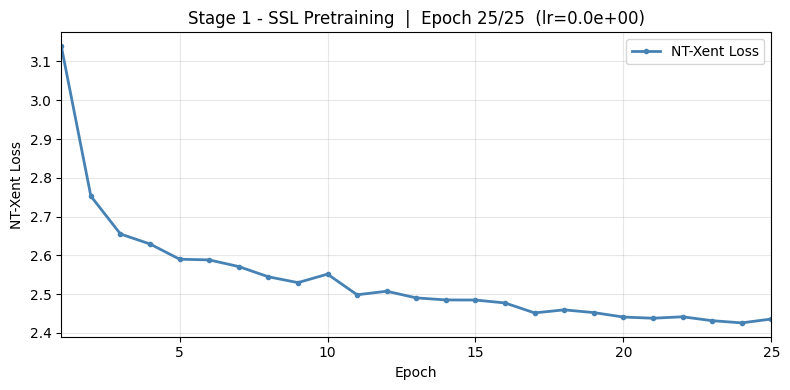

In [15]:
ssl_transform = get_simclr_transforms(IMAGE_SIZE)
ssl_dataset = SimCLRDataset(f'{DATA_ROOT}/train', transform=ssl_transform)
ssl_loader = DataLoader(ssl_dataset, batch_size=BATCH_SIZE,
                        shuffle=True, num_workers=0, drop_last=True)

ssl_model = SimCLR(pretrained=True).to(device)
optimizer = torch.optim.AdamW(ssl_model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=SSL_EPOCHS)

ssl_losses = []
best_ssl_loss = float('inf')

for epoch in range(1, SSL_EPOCHS + 1):
    loss = ssl_train_one_epoch(ssl_model, ssl_loader, optimizer, device,
                               temperature=TEMPERATURE,
                               epoch=epoch, total_epochs=SSL_EPOCHS)
    scheduler.step()
    ssl_losses.append(loss)

    if loss < best_ssl_loss:
        best_ssl_loss = loss
        save_checkpoint(
            path=f'{CHECKPOINT_DIR}/ssl_best.pt',
            model=ssl_model,
            optimizer=optimizer,
            epoch=epoch,
            best_val_f1=None,
            history={'ssl_losses': ssl_losses},
            scheduler=scheduler,
        )

    save_checkpoint(
        path=f'{CHECKPOINT_DIR}/ssl_last.pt',
        model=ssl_model,
        optimizer=optimizer,
        epoch=epoch,
        best_val_f1=None,
        history={'ssl_losses': ssl_losses},
        scheduler=scheduler,
    )

    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, len(ssl_losses) + 1), ssl_losses,
            'steelblue', linewidth=2, marker='o', markersize=3, label='NT-Xent Loss')
    ax.set_xlim(1, SSL_EPOCHS)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('NT-Xent Loss')
    ax.set_title(f'Stage 1 - SSL Pretraining  |  Epoch {epoch}/{SSL_EPOCHS}  '
                 f'(lr={scheduler.get_last_lr()[0]:.1e})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Stage 2: Linear Probing

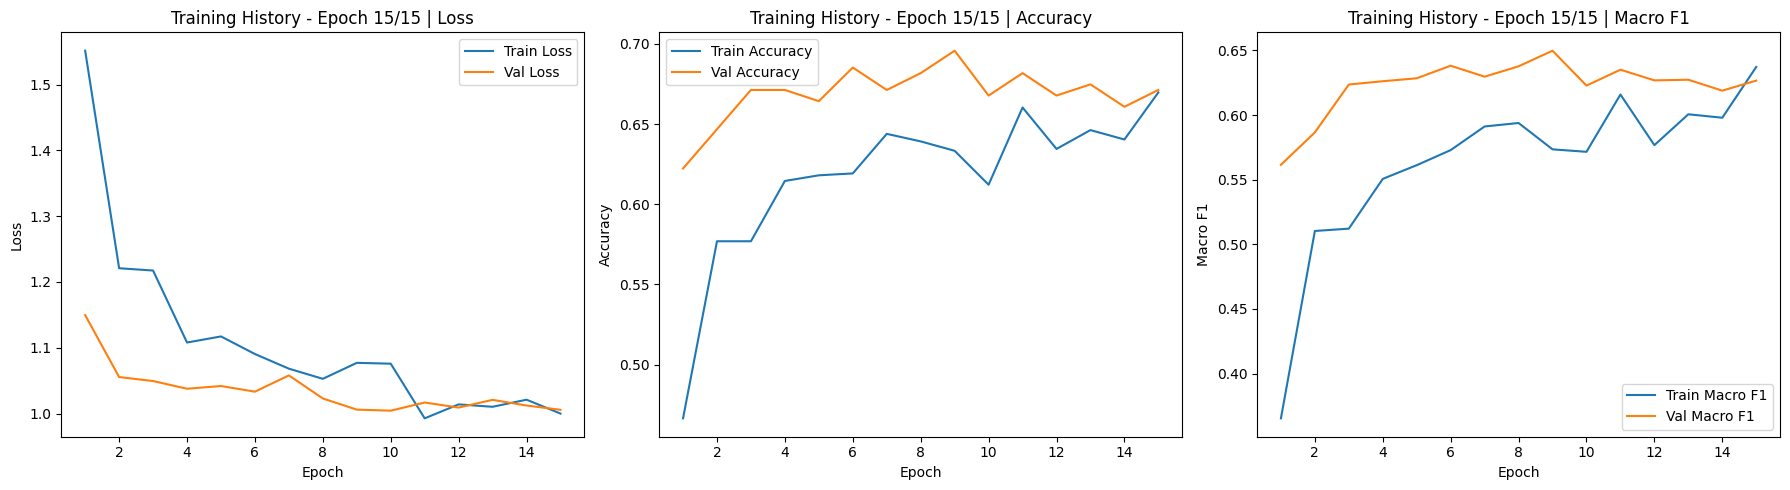

[Probe] Epoch 15/15  val_acc=0.671  val_f1=0.627


In [16]:
train_dataset = PaintingStyleDataset(f'{DATA_ROOT}/train',
                                     transform=get_transforms('train', IMAGE_SIZE))
test_dataset = PaintingStyleDataset(f'{DATA_ROOT}/test',
                                    transform=get_transforms('test', IMAGE_SIZE))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=0)

for p in ssl_model.backbone.parameters():
    p.requires_grad = False

classifier = LinearClassifier(ssl_model.feature_dim, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(classifier.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PROBE_EPOCHS)

probe_combined = torch.nn.ModuleDict({
    'backbone': ssl_model.backbone,
    'classifier': classifier,
})
best_probe_f1 = -1.0

probe_history = init_history()
for epoch in range(1, PROBE_EPOCHS + 1):
    tr_loss, tr_m = classifier_train_one_epoch(
        ssl_model.backbone, classifier, train_loader,
        criterion, optimizer, device, epoch, PROBE_EPOCHS)
    val_loss, val_m = classifier_evaluate(
        ssl_model.backbone, classifier, test_loader,
        criterion, device, epoch, PROBE_EPOCHS)
    scheduler.step()

    probe_history['train_loss'].append(tr_loss)
    probe_history['val_loss'].append(val_loss)
    probe_history['train_accuracy'].append(tr_m['accuracy'])
    probe_history['val_accuracy'].append(val_m['accuracy'])
    probe_history['train_macro_f1'].append(tr_m['macro_f1'])
    probe_history['val_macro_f1'].append(val_m['macro_f1'])

    if val_m['macro_f1'] > best_probe_f1:
        best_probe_f1 = val_m['macro_f1']
        save_checkpoint(
            path=f'{CHECKPOINT_DIR}/probe_best.pt',
            model=probe_combined,
            optimizer=optimizer,
            epoch=epoch,
            best_val_f1=best_probe_f1,
            history=probe_history,
            scheduler=scheduler,
        )

    save_checkpoint(
        path=f'{CHECKPOINT_DIR}/probe_last.pt',
        model=probe_combined,
        optimizer=optimizer,
        epoch=epoch,
        best_val_f1=best_probe_f1,
        history=probe_history,
        scheduler=scheduler,
    )

    plot_training_history_live(probe_history, epoch, PROBE_EPOCHS)
    print(f"[Probe] Epoch {epoch:2d}/{PROBE_EPOCHS}  "
          f"val_acc={val_m['accuracy']:.3f}  val_f1={val_m['macro_f1']:.3f}")


# Stage 3: Full Fine-tuning

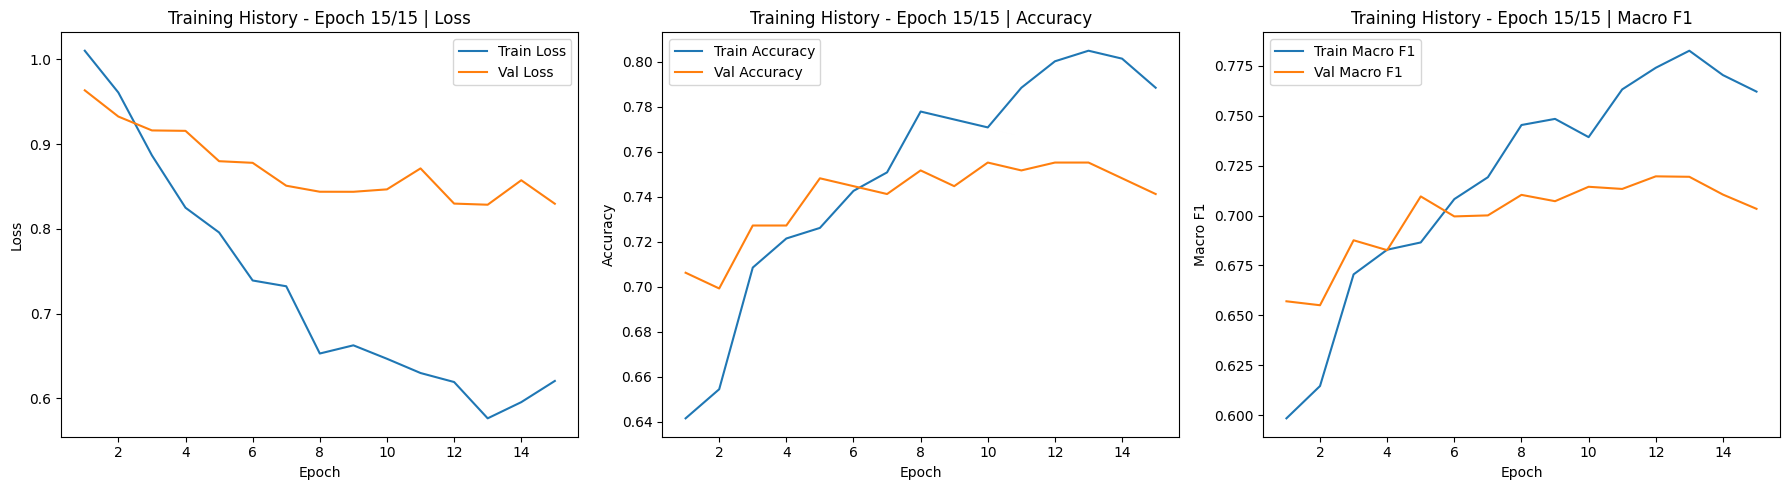

[FT]    Epoch 15/15  val_acc=0.741  val_f1=0.703


In [17]:
for p in ssl_model.backbone.parameters():
    p.requires_grad = True

optimizer = torch.optim.AdamW([
    {'params': ssl_model.backbone.parameters(), 'lr': 3e-5},
    {'params': classifier.parameters(), 'lr': 1e-4},
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINETUNE_EPOCHS)

ft_combined = torch.nn.ModuleDict({
    'backbone': ssl_model.backbone,
    'classifier': classifier,
})
best_ft_f1 = -1.0

ft_history = init_history()
for epoch in range(1, FINETUNE_EPOCHS + 1):
    tr_loss, tr_m = classifier_train_one_epoch(
        ssl_model.backbone, classifier, train_loader,
        criterion, optimizer, device, epoch, FINETUNE_EPOCHS)
    val_loss, val_m = classifier_evaluate(
        ssl_model.backbone, classifier, test_loader,
        criterion, device, epoch, FINETUNE_EPOCHS)
    scheduler.step()

    ft_history['train_loss'].append(tr_loss)
    ft_history['val_loss'].append(val_loss)
    ft_history['train_accuracy'].append(tr_m['accuracy'])
    ft_history['val_accuracy'].append(val_m['accuracy'])
    ft_history['train_macro_f1'].append(tr_m['macro_f1'])
    ft_history['val_macro_f1'].append(val_m['macro_f1'])

    if val_m['macro_f1'] > best_ft_f1:
        best_ft_f1 = val_m['macro_f1']
        save_checkpoint(
            path=f'{CHECKPOINT_DIR}/ft_best.pt',
            model=ft_combined,
            optimizer=optimizer,
            epoch=epoch,
            best_val_f1=best_ft_f1,
            history=ft_history,
            scheduler=scheduler,
        )

    save_checkpoint(
        path=f'{CHECKPOINT_DIR}/ft_last.pt',
        model=ft_combined,
        optimizer=optimizer,
        epoch=epoch,
        best_val_f1=best_ft_f1,
        history=ft_history,
        scheduler=scheduler,
    )

    plot_training_history_live(ft_history, epoch, FINETUNE_EPOCHS)
    print(f"[FT]    Epoch {epoch:2d}/{FINETUNE_EPOCHS}  "
          f"val_acc={val_m['accuracy']:.3f}  val_f1={val_m['macro_f1']:.3f}")


## Convergence Plots

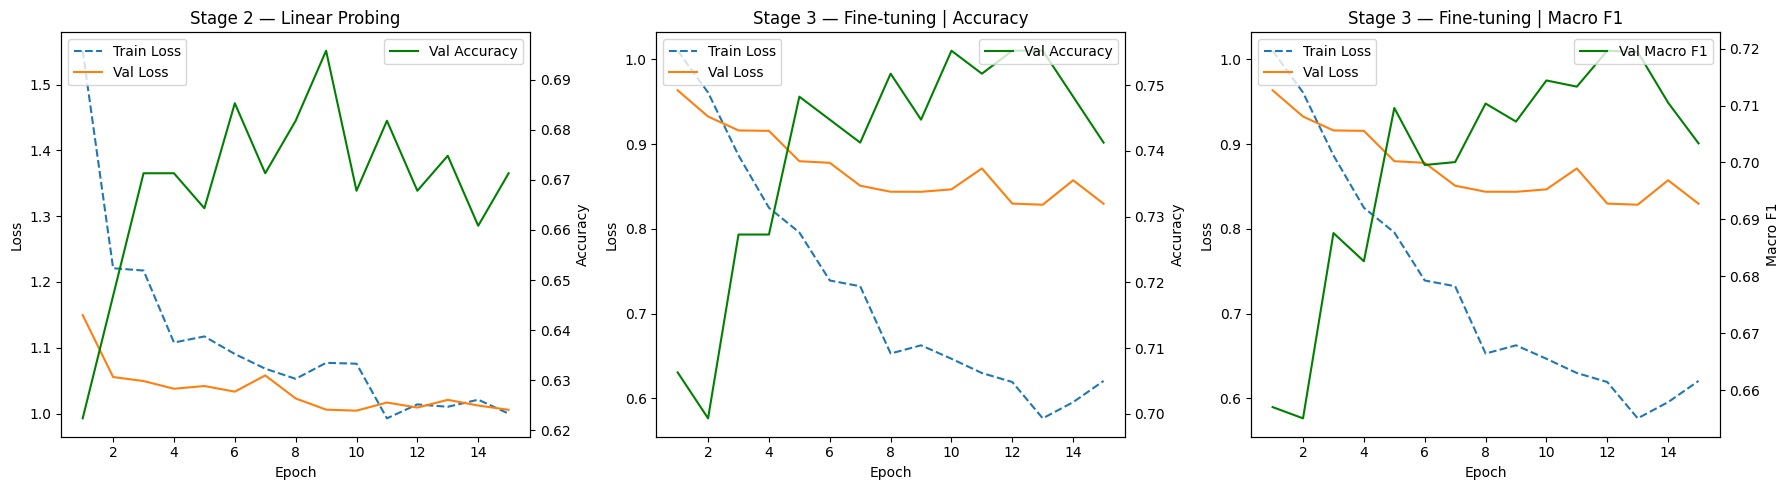

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_stage(ax, history, title, key_metric, ylabel):
    ep = range(1, len(history['train_loss']) + 1)
    ax.plot(ep, history['train_loss'], label='Train Loss', linestyle='--')
    ax.plot(ep, history['val_loss'], label='Val Loss')
    ax2 = ax.twinx()
    ax2.plot(ep, history[f'val_{key_metric}'], color='green', label=f'Val {ylabel}')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax2.set_ylabel(ylabel)
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

plot_stage(axes[0], probe_history, 'Stage 2 — Linear Probing', 'accuracy', 'Accuracy')
plot_stage(axes[1], ft_history, 'Stage 3 — Fine-tuning | Accuracy', 'accuracy', 'Accuracy')
plot_stage(axes[2], ft_history, 'Stage 3 — Fine-tuning | Macro F1', 'macro_f1', 'Macro F1')
plt.tight_layout()
plt.show()


## Test Set Evaluation

In [19]:
ssl_combined, _, _, _, _, _ = load_checkpoint(
    f'{CHECKPOINT_DIR}/ft_best.pt',
    torch.nn.ModuleDict({
        'backbone': SimCLR(pretrained=False).backbone,
        'classifier': LinearClassifier(SimCLR(pretrained=False).feature_dim, NUM_CLASSES),
    }).to(device),
    optimizer=None,
    map_location=str(device),
)

test_loss_ssl, test_metrics_ssl = classifier_evaluate(
    ssl_combined['backbone'],
    ssl_combined['classifier'],
    test_loader,
    criterion,
    device,
)

print("SSL (SimCLR + Fine-tuning) Test Results")
print("Test Loss:", round(test_loss_ssl, 4))
print("Test Accuracy:", round(test_metrics_ssl['accuracy'], 4))
print("Test Macro F1:", round(test_metrics_ssl['macro_f1'], 4))


/Users/arpinejanunts/Desktop/iml2-painting-style/src/iml2_painting_style/checkpoints.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_l

Validation:   0%|          | 0/9 [00:00<?, ?it/s]

SSL (SimCLR + Fine-tuning) Test Results
Test Loss: 0.8298
Test Accuracy: 0.7552
Test Macro F1: 0.7196
